### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [ ]:
arxiv.invoke("Attention is all you need")

In [4]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches '

In [6]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [7]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\arunk\AppData\Local\Temp\ipykernel_1460\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [8]:
tavily.invoke("Provide me latest movie reviews of Dhurandhar-2")

[{'title': "Dhurandhar 2 Movie Review: Ranveer Singh's 4-hour marathon ...",
  'url': 'https://indianexpress.com/article/entertainment/movie-review/dhurandhar-2-movie-review-aditya-dhar-ranveer-singh-10589113/',
  'content': 'The first part had left me conflicted: yes, its intent was propaganda, but it was wrapped in pacy, racy story-telling, embellished with some terrific musical flourishes, and I was quite taken by all the to-ing and fro-ing, and shooting and scooting. In the second part, to paraphrase a character, itna mazaa nahin aaya.\n\nDhurandhar 2 cast: Ranveer Singh, Arjun Rampal, Sanjay Dutt, R Madhavan, Sara Arjun, Rakesh Bedi, Danish Pandor, Gaurav Gera, Manav Gohil, Raj Zutshi  \nDhurandhar 2 director: Aditya Dhar  \nDhurandhar 2 rating: 2 stars\n\nClick here to follow Screen Digital on YouTube and stay updated with the latest from the world of cinema. [...] Dhurandhar 2 Movie Review LIVE Updates: Read Here\n\nI missed Akshaye Khanna’s stylish Rehman Dakait, the Baloch ove

In [ ]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [10]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")

llm_with_tools=llm.bind_tools(tools)

In [11]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent AI news. I need to figure out which tool to use here. Let me check the available functions.\n\nFirst, there\'s the arxiv function, which is for scientific papers in fields like physics and computer science. But the user is asking for news, not research papers. So maybe arxiv isn\'t the best fit here.\n\nNext, the wikipedia function. Wikipedia has general information, but it might not have the most up-to-date news. Plus, Wikipedia articles are more about established topics rather than recent events.\n\nThen there\'s the tavily_search_results_json function, which is described as a search engine optimized for current events. That sounds perfect for finding recent news on AI. The user wants the latest updates, so using a search engine that focuses on current information makes sense.\n\nI should call tavily_search_results_json with the query "recent AI news". That should retrieve the most rele

In [12]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'v74nfryb6',
  'type': 'tool_call'}]

In [13]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

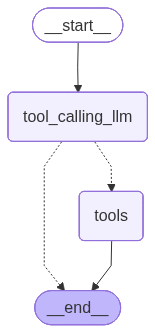

In [14]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [15]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (x903wv2h6)
 Call ID: x903wv2h6
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [16]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for March 2026")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for March 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (ssef3qakn)
 Call ID: ssef3qakn
  Args:
    query: top 10 recent AI news March 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI INTELLIGENCE | Weekly Top 10 (3/19/26) - Dwealth.news", "url": "https://dwealth.news/2026/03/ai-intelligence-weekly-top-10-3-19-26/", "content": "Dwealth.news Logo\nDwealth.news Logo\n\n# AI INTELLIGENCE | Weekly Top 10 (3/19/26)\n\nThis week highlighted a deepening shift from AI experimentation to full-scale deployment across enterprise, government, and financial systems. Major technology firms pushed forward with new model capabilities and infrastructure expansion, while financial institutions accelerated adoption in payme

In [17]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (4gkyz00nf)
 Call ID: 4gkyz00nf
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches 


In [18]:
messages=graph.invoke({"messages":HumanMessage(content="What is the squre root of 123456789")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the squre root of 123456789
================================== Ai Message ==================================

The square root of 123,456,789 is approximately **11,111.11**. This is an approximation since 123,456,789 is not a perfect square. The exact value would be an irrational number, but for practical purposes, this decimal approximation is sufficient.


In [20]:
messages=graph.invoke({"messages":HumanMessage(content="What is current status petrol and LPG GAS in India year 2026?")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is current status petrol and LPG GAS in India year 2026?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (ek31qy6k2)
 Call ID: ek31qy6k2
  Args:
    query: current status petrol and LPG gas in India 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Fuel crisis updates: PM Modi to interact with CMs - The Hindu", "url": "https://www.thehindu.com/news/national/lpg-fuel-petrol-crisis-west-asia-strait-of-hormuz-us-israel-iran-live-updates/article70786856.ece", "content": "India assures 60 days of fuel stock, dismissing shortage claims as misinformation, with petrol pumps adequately stocked nationwide.\n\nMeghalaya has sought a substantial increase in LPG supply from the Centre after facing reduced deliveries, particularly of commercial cylinders, affec